In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ipl_data = pd.read_csv('deliveries.csv')
ipl_data

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [3]:
ipl_data.shape

(179078, 21)

In [4]:
ipl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [4]:
ipl_data.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

In [5]:
ipl_data.groupby('match_id')['total_runs'].sum()

match_id
1        379
2        371
3        367
4        327
5        299
        ... 
11347    280
11412    276
11413    341
11414    317
11415    309
Name: total_runs, Length: 756, dtype: int64

In [6]:
run_total_match = ipl_data.groupby(["match_id","inning","batting_team"])["total_runs"].sum()
run_total_match

match_id  inning  batting_team               
1         1       Sunrisers Hyderabad            207
          2       Royal Challengers Bangalore    172
2         1       Mumbai Indians                 184
          2       Rising Pune Supergiant         187
3         1       Gujarat Lions                  183
                                                ... 
11413     2       Delhi Capitals                 170
11414     1       Delhi Capitals                 155
          2       Chennai Super Kings            162
11415     1       Mumbai Indians                 152
          2       Chennai Super Kings            157
Name: total_runs, Length: 1528, dtype: int64

In [7]:
winners = run_total_match.groupby('match_id').max()
winners

match_id
1        207
2        187
3        184
4        164
5        157
        ... 
11347    143
11412    140
11413    171
11414    162
11415    157
Name: total_runs, Length: 756, dtype: int64

# winner teams

In [8]:
winner_team = run_total_match.groupby('match_id').idxmax()
winner_team

match_id
1                (1, 1, Sunrisers Hyderabad)
2             (2, 2, Rising Pune Supergiant)
3              (3, 2, Kolkata Knight Riders)
4                    (4, 2, Kings XI Punjab)
5        (5, 1, Royal Challengers Bangalore)
                        ...                 
11347      (11347, 1, Kolkata Knight Riders)
11412             (11412, 2, Mumbai Indians)
11413        (11413, 1, Sunrisers Hyderabad)
11414        (11414, 2, Chennai Super Kings)
11415        (11415, 2, Chennai Super Kings)
Name: total_runs, Length: 756, dtype: object

In [9]:
winning_team = winner_team.apply(lambda x : x[2])
winning_team

match_id
1                Sunrisers Hyderabad
2             Rising Pune Supergiant
3              Kolkata Knight Riders
4                    Kings XI Punjab
5        Royal Challengers Bangalore
                    ...             
11347          Kolkata Knight Riders
11412                 Mumbai Indians
11413            Sunrisers Hyderabad
11414            Chennai Super Kings
11415            Chennai Super Kings
Name: total_runs, Length: 756, dtype: object

# winning counts

In [10]:
count_winning_team = winning_team.value_counts()
count_winning_team

total_runs
Mumbai Indians                 109
Chennai Super Kings            101
Kolkata Knight Riders           93
Royal Challengers Bangalore     83
Kings XI Punjab                 78
Rajasthan Royals                74
Delhi Daredevils                73
Sunrisers Hyderabad             64
Deccan Chargers                 29
Gujarat Lions                   14
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Delhi Capitals                   6
Rising Pune Supergiants          4
Name: count, dtype: int64

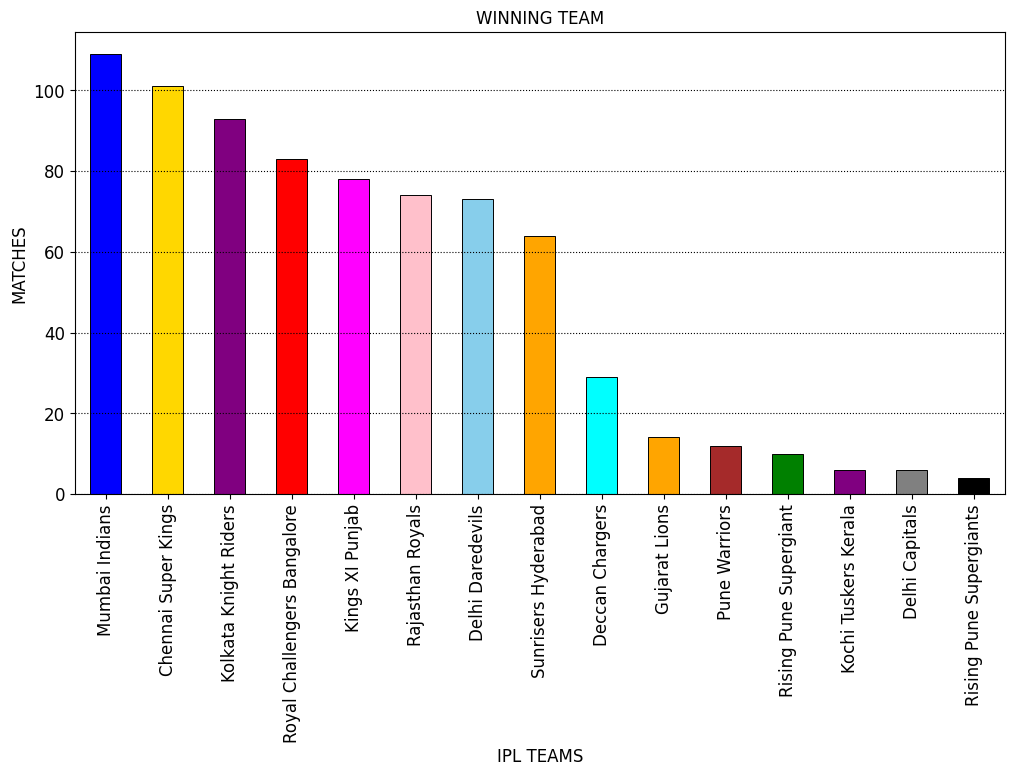

In [11]:
# fig, ax = plt.subplots(figsize = (12,6))
plt.figure(figsize = (12,6))
c=['blue','gold','purple','red','magenta','pink','skyblue','orange','cyan','orange','brown','green','purple','gray','black']
count_winning_team.plot(kind = 'bar',color = c,edgecolor="black",linewidth=0.7)
plt.xlabel('IPL TEAMS',fontsize=12)
plt.ylabel('MATCHES',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('WINNING TEAM')
plt.grid(axis='y', linestyle=':',color="black")
plt.show()

# Top batsman in terms of runs

In [12]:
max_run = ipl_data.groupby('batsman')['total_runs'].sum().sort_values(ascending=False).head(10)
max_run

batsman
SK Raina          5651
V Kohli           5616
RG Sharma         5057
DA Warner         4975
S Dhawan          4876
CH Gayle          4873
RV Uthappa        4703
MS Dhoni          4691
AB de Villiers    4583
G Gambhir         4485
Name: total_runs, dtype: int64

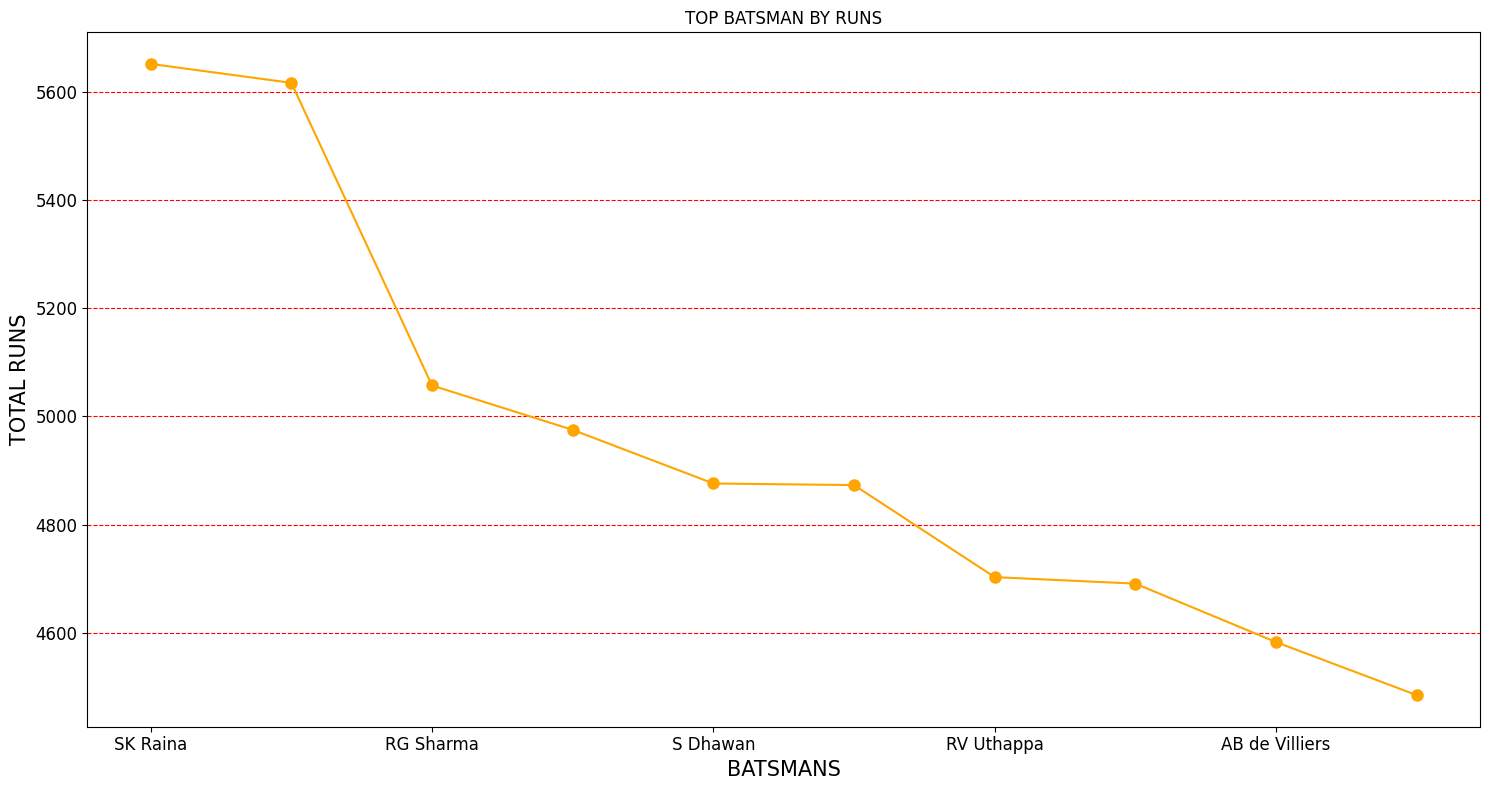

In [13]:
plt.figure(figsize=(15,8))
max_run.plot(kind='line',color = 'orange',marker='o',markersize=8)
plt.xlabel('BATSMANS',fontsize=15)
plt.ylabel('TOTAL RUNS',fontsize=15)
plt.title('TOP BATSMAN BY RUNS')
plt.grid(axis='y',linestyle = '--',color="red")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Orange Cap Holder :- SK Raina

# Most successful bowlers in terms of wickets taken

In [14]:
wicket_taker = ipl_data.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)
wicket_taker

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
Name: player_dismissed, dtype: int64

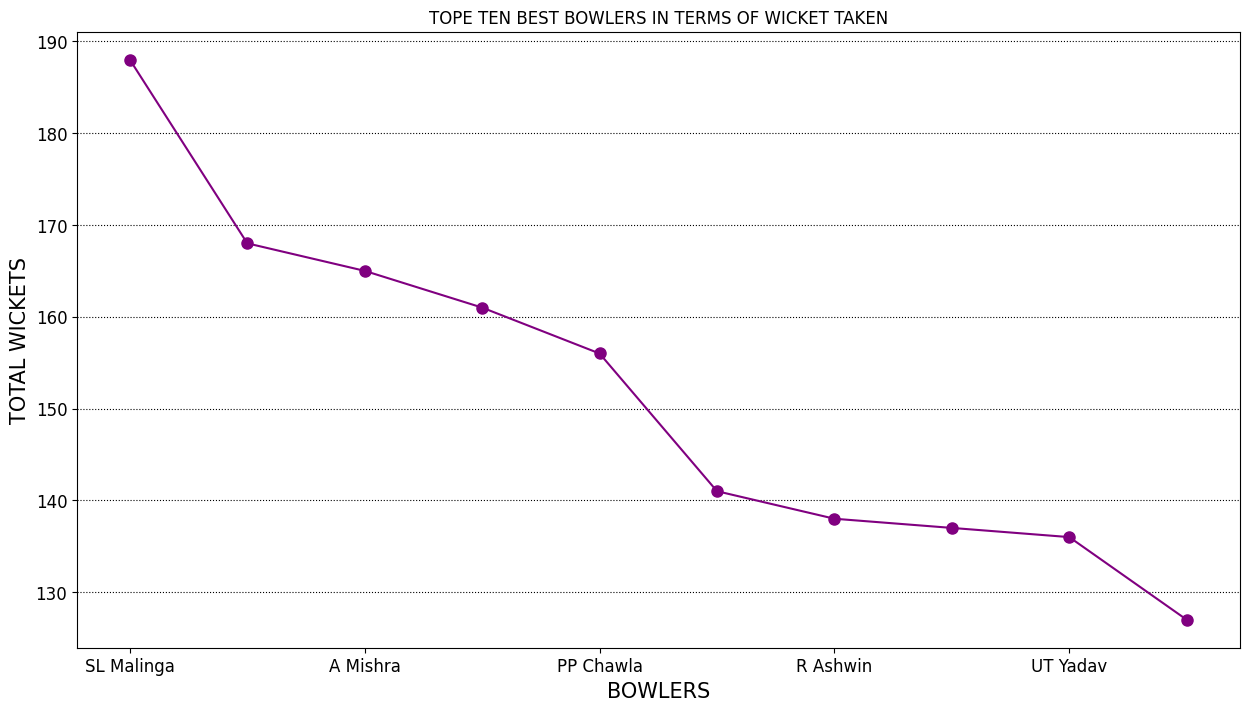

In [15]:
plt.figure(figsize=(15,8))
wicket_taker.plot(kind='line',color = 'purple',marker="o",markersize=8)
plt.xlabel('BOWLERS',fontsize=15)
plt.ylabel('TOTAL WICKETS',fontsize=15)
plt.title('TOPE TEN BEST BOWLERS IN TERMS OF WICKET TAKEN')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y',linestyle = ':',color="black")
plt.show()

Purple Cap Holder :- SL Malinga

# Top batsmen with highest strike rate

In [16]:
batsmen_strike_rate = ipl_data.groupby('batsman')['total_runs'].sum() / ipl_data.groupby('batsman')['ball'].sum()
batsmen_strike_rate = batsmen_strike_rate.sort_values(ascending=False).head(10)
batsmen_strike_rate

batsman
S Sharma      1.000000
I Malhotra    0.583333
Umar Gul      0.571429
SP Narine     0.500585
M Ali         0.499232
ER Dwivedi    0.491525
S Curran      0.484694
AD Russell    0.482008
KK Cooper     0.478431
K Gowtham     0.462006
dtype: float64

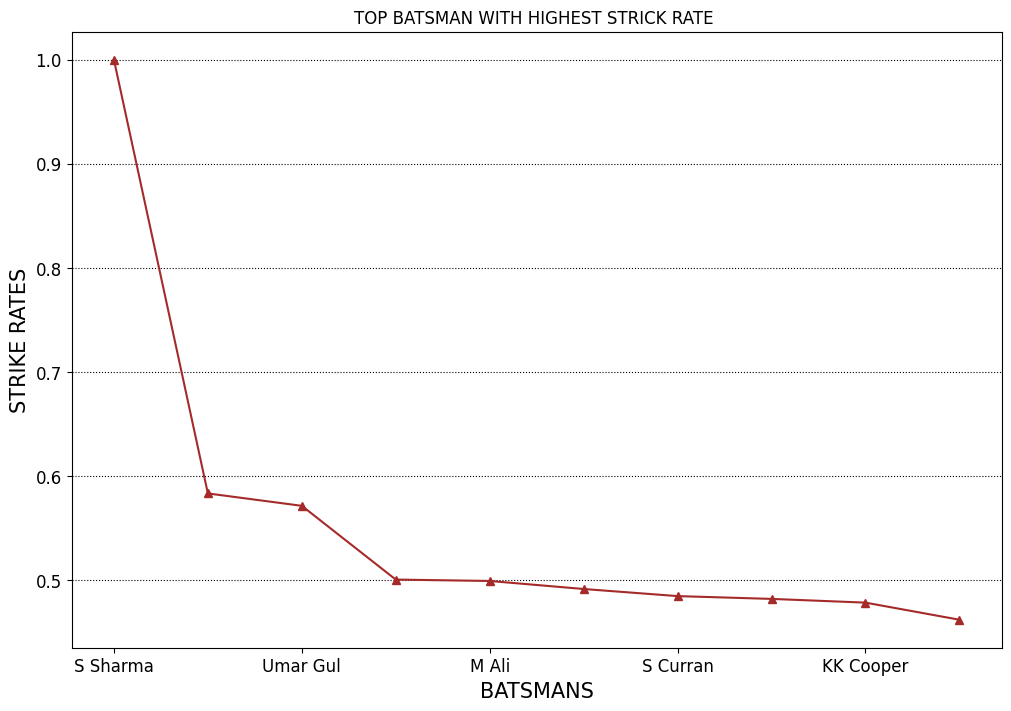

In [17]:
plt.figure(figsize=(12,8))
batsmen_strike_rate.plot(kind='line',color = 'brown',marker="^")
plt.xlabel('BATSMANS',fontsize=15)
plt.ylabel('STRIKE RATES',fontsize=15)
plt.title('TOP BATSMAN WITH HIGHEST STRICK RATE ')
plt.grid(axis='y',linestyle = ':',color="black")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Extras conceded by each team

In [18]:
extras_conceded = ipl_data.groupby('bowling_team')['extra_runs'].sum().sort_values(ascending=False)
extras_conceded

bowling_team
Mumbai Indians                 1612
Royal Challengers Bangalore    1558
Kings XI Punjab                1453
Kolkata Knight Riders          1372
Delhi Daredevils               1268
Rajasthan Royals               1245
Chennai Super Kings            1213
Deccan Chargers                 659
Sunrisers Hyderabad             656
Pune Warriors                   335
Gujarat Lions                   188
Delhi Capitals                  116
Rising Pune Supergiant          111
Kochi Tuskers Kerala            110
Rising Pune Supergiants         108
Name: extra_runs, dtype: int64

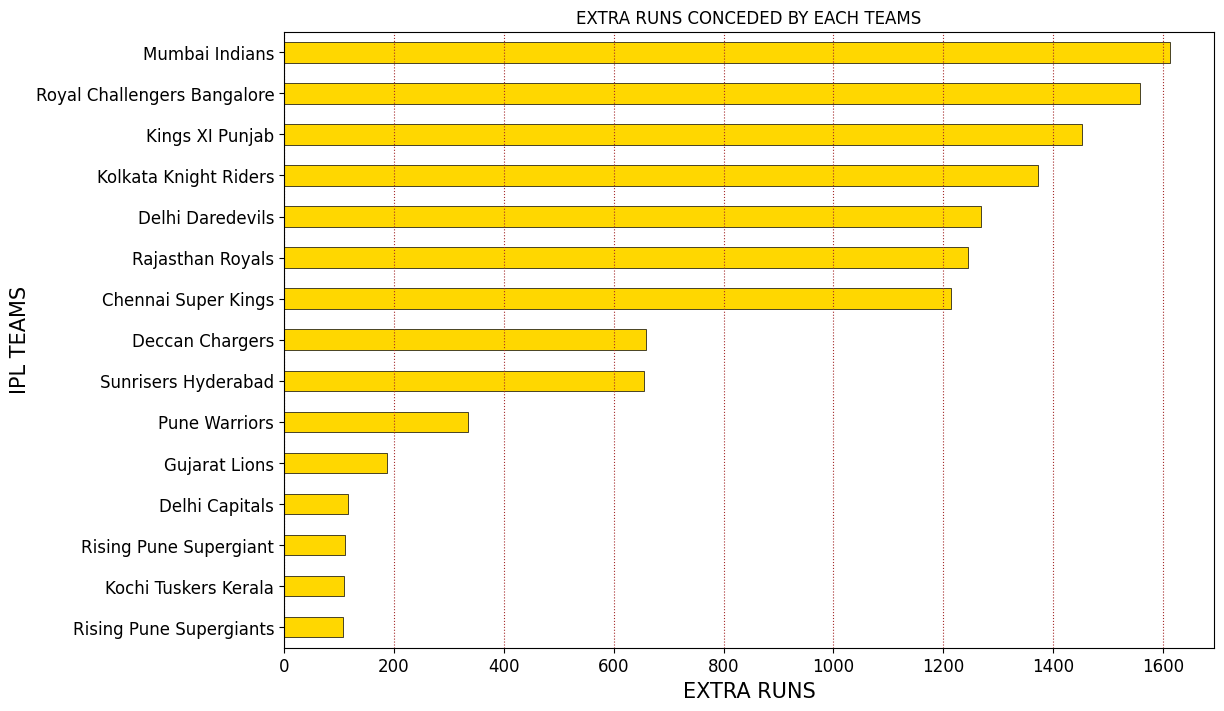

In [20]:
plt.figure(figsize=(12,8))
extras_conceded.plot(kind='barh',color = 'gold',edgecolor="black",linewidth=0.5)
plt.ylabel('IPL TEAMS',fontsize=15)
plt.xlabel('EXTRA RUNS',fontsize=15)
plt.title('EXTRA RUNS CONCEDED BY EACH TEAMS')
plt.grid(axis='x',linestyle = ':',color="brown")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.show()

# Powerplay scores

In [21]:
powerplay_scores = ipl_data[ipl_data['over'] <= 6].groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
powerplay_scores

batting_team
Mumbai Indians                 8498
Kolkata Knight Riders          8370
Kings XI Punjab                8296
Royal Challengers Bangalore    8111
Chennai Super Kings            7503
Delhi Daredevils               7392
Rajasthan Royals               6605
Sunrisers Hyderabad            5238
Deccan Chargers                3417
Pune Warriors                  1895
Gujarat Lions                  1559
Delhi Capitals                  844
Rising Pune Supergiant          785
Kochi Tuskers Kerala            680
Rising Pune Supergiants         638
Name: total_runs, dtype: int64

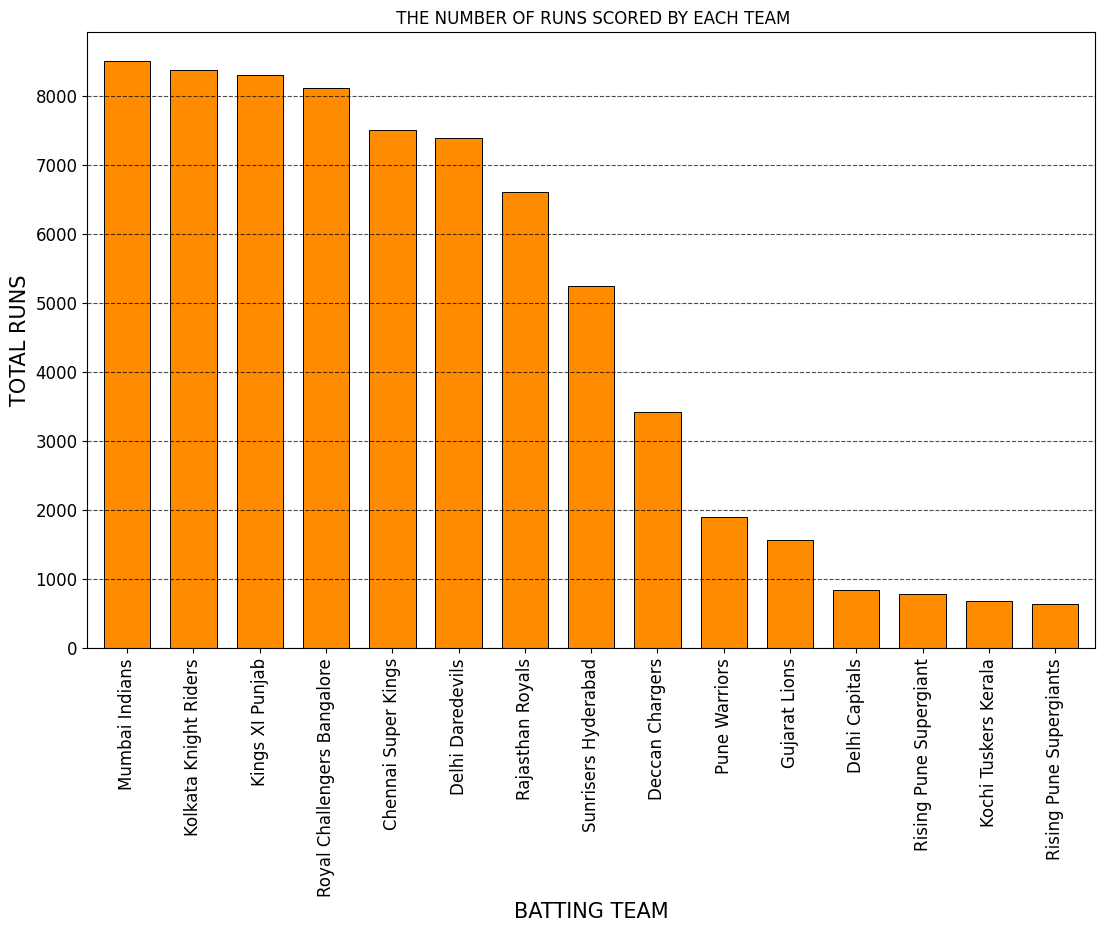

In [22]:
plt.figure(figsize=(13,8))
powerplay_scores.plot(kind ='bar',width=0.7,color='darkorange',edgecolor="black",linewidth=0.7)
plt.xlabel('BATTING TEAM',fontsize=15)
plt.ylabel('TOTAL RUNS',fontsize=15)
plt.title(' THE NUMBER OF RUNS SCORED BY EACH TEAM')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y',linestyle = '--',color="black",alpha=0.7)
plt.show()

# Highest partnerships by runs

In [23]:
partnerships = ipl_data.groupby(['match_id', 'batsman', 'non_striker'])['total_runs'].sum().reset_index()
partnerships = partnerships.sort_values(by='total_runs',ascending=False).head(10)
partnerships

,match_id,batsman,non_striker,total_runs
14028,562,AB de Villiers,V Kohli,138
15400,620,AB de Villiers,V Kohli,132
10324,411,CH Gayle,TM Dilshan,130
9300,372,CH Gayle,V Kohli,128
7447,296,AC Gilchrist,SE Marsh,126
8328,331,DA Warner,NV Ojha,119
1807,72,AC Gilchrist,VVS Laxman,116
17601,11147,J Bairstow,DA Warner,116
9091,363,RG Sharma,HH Gibbs,113
891,36,DA Warner,S Dhawan,105


# Top fielders in terms of catches taken

In [24]:
catches = ipl_data[ipl_data['dismissal_kind'] == 'caught'].groupby('fielder')['fielder'].count()
catches = catches.sort_values(ascending=False).head(10)
catches

fielder
KD Karthik        109
SK Raina           99
MS Dhoni           98
AB de Villiers     93
RV Uthappa         84
RG Sharma          82
KA Pollard         76
V Kohli            73
PA Patel           69
S Dhawan           68
Name: fielder, dtype: int64

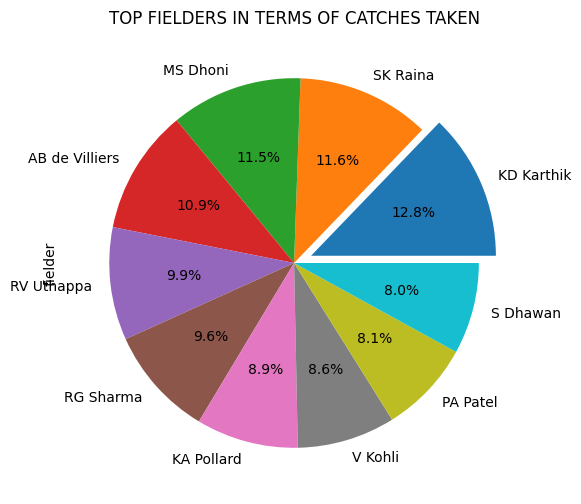

In [25]:
plt.figure(figsize=(10,6))
catches.plot(kind='pie',color = 'gray',autopct="%1.1f%%",explode=[0.1,0,0,0,0,0,0,0,0,0])
plt.title('TOP FIELDERS IN TERMS OF CATCHES TAKEN')
plt.show()

# Top bowlers in terms of economy rate

In [26]:
bowlers_economy = ipl_data.groupby('bowler')['total_runs'].sum() / ipl_data.groupby('bowler')['over'].sum()
bowlers_economy = bowlers_economy.sort_values(ascending=False).head(10)
bowlers_economy

bowler
SA Yadav         1.333333
RR Bose          1.000000
RA Shaikh        0.611111
Shoaib Akhtar    0.509434
I Malhotra       0.479167
P Prasanth       0.375000
Sunny Gupta      0.307190
RR Bhatkal       0.307018
NB Singh         0.285714
GH Vihari        0.280576
dtype: float64

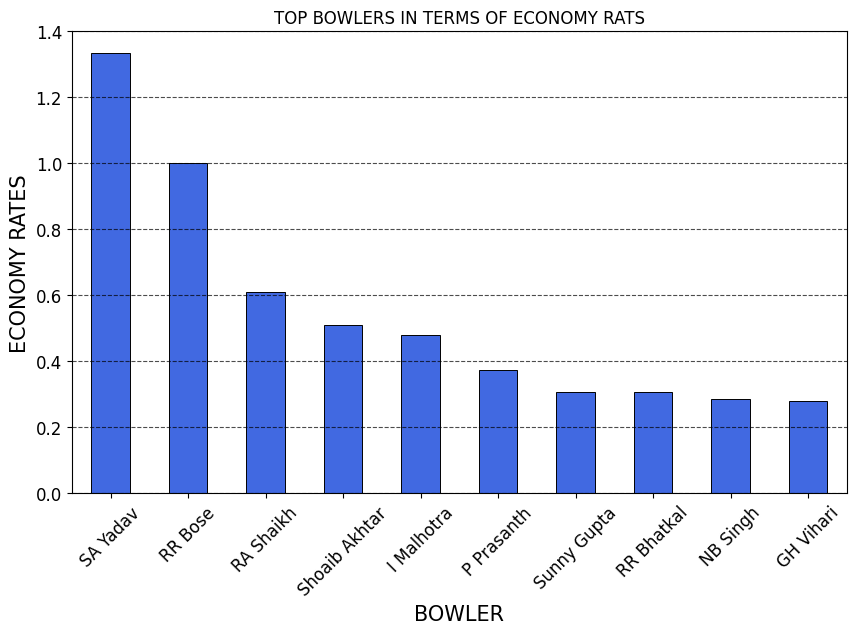

In [27]:
plt.figure(figsize=(10,6))
bowlers_economy.plot(kind='bar',color = 'royalblue',edgecolor="black",linewidth=0.7)
plt.xlabel('BOWLER',fontsize=15)
plt.ylabel('ECONOMY RATES',fontsize=15)
plt.xticks(rotation=45)
plt.title('TOP BOWLERS IN TERMS OF ECONOMY RATS')
plt.grid(axis='y',linestyle = '--',color="black",alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()